# Validação do Modelo DeepHestonHybrid (Dados 2024)

Este notebook realiza a validação qualitativa e quantitativa do modelo híbrido (LSTM + PINN Heston) utilizando dados de opções de 2024 (Out-of-Sample).

**Objetivos:**
1.  **Métricas de Erro:** Calcular RMSE, MAE, MAPE e R² para os preços previstos.
2.  **Análise de Volatilidade:** Comparar a Volatilidade Implícita de Mercado vs. Modelo.
3.  **Visualização:** Plots de dispersão, histogramas de erro e superfícies de volatilidade.
4.  **Diagnóstico:** Identificar viés por moneyness e time-to-maturity.

In [1]:
# 1. Configuração e Imports
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import norm
from scipy.optimize import brentq
from torch.utils.data import DataLoader, TensorDataset

# Imports do Projeto
from src.model import DeepHestonHybrid
from src.config import MODEL_CONFIG, PATHS, TRAINING_CONFIG
from src.data_loader import criar_dataset_hibrido, carregar_taxa_juros

# Configuração de Plot
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [2]:
# 2. Funções Auxiliares (Black-Scholes & Implied Vol)

def bs_call_price(S, K, T, r, sigma):
    """Preço da Call Europeia via Black-Scholes"""
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    r = np.asarray(r, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    
    price = np.zeros_like(S)
    mask = (T > 0)
    
    if np.any(mask):
        S_m, K_m, T_m, r_m, sig_m = S[mask], K[mask], T[mask], r[mask], sigma[mask]
        d1 = (np.log(S_m/K_m) + (r_m + 0.5 * sig_m**2) * T_m) / (sig_m * np.sqrt(T_m))
        d2 = d1 - sig_m * np.sqrt(T_m)
        price[mask] = S_m * norm.cdf(d1) - K_m * np.exp(-r_m * T_m) * norm.cdf(d2)
        
    # Payoff intrínseco para T=0
    price[~mask] = np.maximum(S[~mask] - K[~mask], 0.0)
    return price

def implied_volatility(price, S, K, T, r):
    """Calcula Volatilidade Implícita via Brentq"""
    def objective(sigma):
        return bs_call_price(S, K, T, r, sigma) - price
    
    try:
        # Busca raiz entre 0.1% e 500%
        return brentq(objective, 1e-4, 5.0)
    except:
        return np.nan

In [3]:
# 3. Carregamento de Dados (2024)

# Caminhos
RAW_2024_DIR = os.path.join(PATHS['raw_data'], 'Databricks') # Ajuste se necessário
SELIC_PATH = PATHS['selic_data']

print("Carregando dados de 2024...")
df_juros = carregar_taxa_juros(SELIC_PATH)

# Usa a função do data_loader para processar a pasta de 2024
# Nota: criar_dataset_hibrido retorna (dataset, data_stats)
# O dataset já é um TensorDataset pronto para o DataLoader
val_dataset, _ = criar_dataset_hibrido(RAW_2024_DIR, df_juros)

if val_dataset is None:
    raise ValueError("Não foi possível carregar dados de validação.")

print(f"Dados carregados: {len(val_dataset)} amostras.")

# DataLoader
val_loader = DataLoader(val_dataset, batch_size=4096, shuffle=False)

# Para análise posterior, precisamos reconstruir o DataFrame
# O TensorDataset tem: X_seq, X_phy, y, X_time, weights
# Vamos extrair para criar df_val
X_phy_tensor = val_dataset.tensors[1]
y_tensor = val_dataset.tensors[2]
X_time_tensor = val_dataset.tensors[3]

# Reconstruir DataFrame para análise
# Desnormalizar para análise (usando stats do treino)
STATS_PATH = os.path.join(PATHS['model_save_dir'], 'data_stats.json')
with open(STATS_PATH, 'r') as f:
    data_stats = json.load(f)

S_min, S_max = data_stats['S_min'], data_stats['S_max']
K_min, K_max = data_stats['K_min'], data_stats['K_max']
T_max = data_stats['T_max']

# Converter tensores para numpy
S_norm = X_phy_tensor[:, 0].numpy()
K_norm = X_phy_tensor[:, 1].numpy()
T_norm = X_phy_tensor[:, 2].numpy()
r = X_phy_tensor[:, 3].numpy()
premium = y_tensor.flatten().numpy()
timestamps = X_time_tensor.flatten().numpy()

# Desnormalização
spot_price = S_norm * (S_max - S_min) + S_min
strike = K_norm * (K_max - K_min) + K_min
time_to_maturity = T_norm * T_max

df_val = pd.DataFrame({
    'spot_price': spot_price,
    'strike': strike,
    'time_to_maturity': time_to_maturity,
    'risk_free_rate': r,
    'premium': premium,
    'time': pd.to_datetime(timestamps, unit='s')
})


Carregando dados de 2024...
[INFO] Lendo arquivos de opções em: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\dados\brutos\Databricks
[INFO] Ativos encontrados: ['ABEV' 'B3SA' 'BBAS' 'BBDC' 'ITUB' 'MGLU' 'PETR' 'VALE']
[INFO] Gerando sequências temporais...
[INFO] Dataset Final: 1022188 amostras.
Dados carregados: 1022188 amostras.


In [4]:
# 4. Carregar Modelo e Inferência

print("Carregando modelo...")
# Ajuste de Configuração para compatibilidade com Checkpoint salvo
# O checkpoint foi treinado com 4 camadas e 64 neurônios, mas o config atual está com 6/128.
model_config = MODEL_CONFIG.copy()
model_config['pinn_hidden_layers'] = 4
model_config['pinn_neurons'] = 64

model = DeepHestonHybrid(config=model_config, data_stats=data_stats)
MODEL_WEIGHTS = os.path.join(PATHS['model_save_dir'], 'best_model_weights.pth')
model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=device))
model.to(device)
model.eval()

print("Realizando inferência...")
preds = []
heston_params = []

with torch.no_grad():
    for x_seq, x_phy, _, _, _ in tqdm(val_loader):
        x_seq = x_seq.to(device)
        x_phy = x_phy.to(device)
        
        out = model(x_seq, x_phy)
        preds.append(out['price'].cpu().numpy().flatten())
        
        # Extrair parâmetros Heston médios do batch (opcional)
        # params = [p.cpu().numpy() for p in out['heston_params']]
        # heston_params.append(params)

preds = np.concatenate(preds)

# Adicionar ao DataFrame
df_val['model_price'] = preds
df_val['error'] = df_val['model_price'] - df_val['premium']
df_val['abs_error'] = df_val['error'].abs()
df_val['sq_error'] = df_val['error'] ** 2

Carregando modelo...
Realizando inferência...


100%|██████████| 250/250 [00:18<00:00, 13.51it/s]


In [5]:
# 5. Métricas de Erro

rmse = np.sqrt(df_val['sq_error'].mean())
mae = df_val['abs_error'].mean()
mape = (df_val['abs_error'] / df_val['premium']).replace([np.inf, -np.inf], np.nan).mean() * 100
r2 = 1 - (df_val['sq_error'].sum() / ((df_val['premium'] - df_val['premium'].mean())**2).sum())

print("="*30)
print("MÉTRICAS DE VALIDAÇÃO (2024)")
print("="*30)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")
print("="*30)

# Diagnóstico de Predições
print("\nExemplo de Predições:")
print(df_val[['spot_price', 'strike', 'time_to_maturity', 'premium', 'model_price', 'error']].head(10))

print("\nEstatísticas do Erro:")
print(df_val['error'].describe())

# Verificar se data_stats parece correto
print("\nStats de Normalização usados:")
print(json.dumps(data_stats, indent=2))

MÉTRICAS DE VALIDAÇÃO (2024)
RMSE: 23.5313
MAE:  18.4507
MAPE: 25273.36%
R²:   -7.3737

Exemplo de Predições:
   spot_price    strike  time_to_maturity  premium  model_price      error
0   21.726425  3.787129          0.043806     0.65    18.265625  17.615625
1   21.726425  3.477758          0.057495     0.12    19.352444  19.232443
2   21.726425  3.548070          0.057495     0.18    19.326595  19.146595
3   21.726425  3.618381          0.057495     0.27    19.300018  19.030018
4   21.726425  3.407447          0.057495     0.07    19.377548  19.307549
5   21.726425  4.054312          0.057495     1.46    19.118351  17.658352
6   21.726425  3.969938          0.057495     1.04    19.155823  18.115822
7   21.726425  3.759004          0.057495     0.57    19.244614  18.674614
8   21.726425  3.829315          0.057495     0.72    19.215786  18.495787
9   21.726425  4.110561          0.057495     1.67    19.092735  17.422735

Estatísticas do Erro:
count    1.022188e+06
mean     1.701352e+0

In [6]:
# 6. Cálculo de Volatilidade Implícita (Modelo vs Mercado)

print("Calculando Volatilidade Implícita (pode demorar um pouco)...")

# Amostra para agilizar (opcional, remova .head(1000) para dataset completo)
df_plot = df_val.sample(n=min(5000, len(df_val)), random_state=42).copy()

tqdm.pandas(desc="IV Mercado")
df_plot['iv_market'] = df_plot.progress_apply(
    lambda row: implied_volatility(row['premium'], row['spot_price'], row['strike'], row['time_to_maturity'], row['risk_free_rate']),
    axis=1
)

tqdm.pandas(desc="IV Modelo")
df_plot['iv_model'] = df_plot.progress_apply(
    lambda row: implied_volatility(row['model_price'], row['spot_price'], row['strike'], row['time_to_maturity'], row['risk_free_rate']),
    axis=1
)

# Remover falhas de cálculo
df_plot_iv = df_plot.dropna(subset=['iv_market', 'iv_model'])
print(f"Amostras com IV válido (Mercado & Modelo): {len(df_plot_iv)} de {len(df_plot)}")

Calculando Volatilidade Implícita (pode demorar um pouco)...


IV Modelo: 100%|██████████| 5000/5000 [00:00<00:00, 5251.89it/s]

Amostras com IV válido (Mercado & Modelo): 0 de 5000


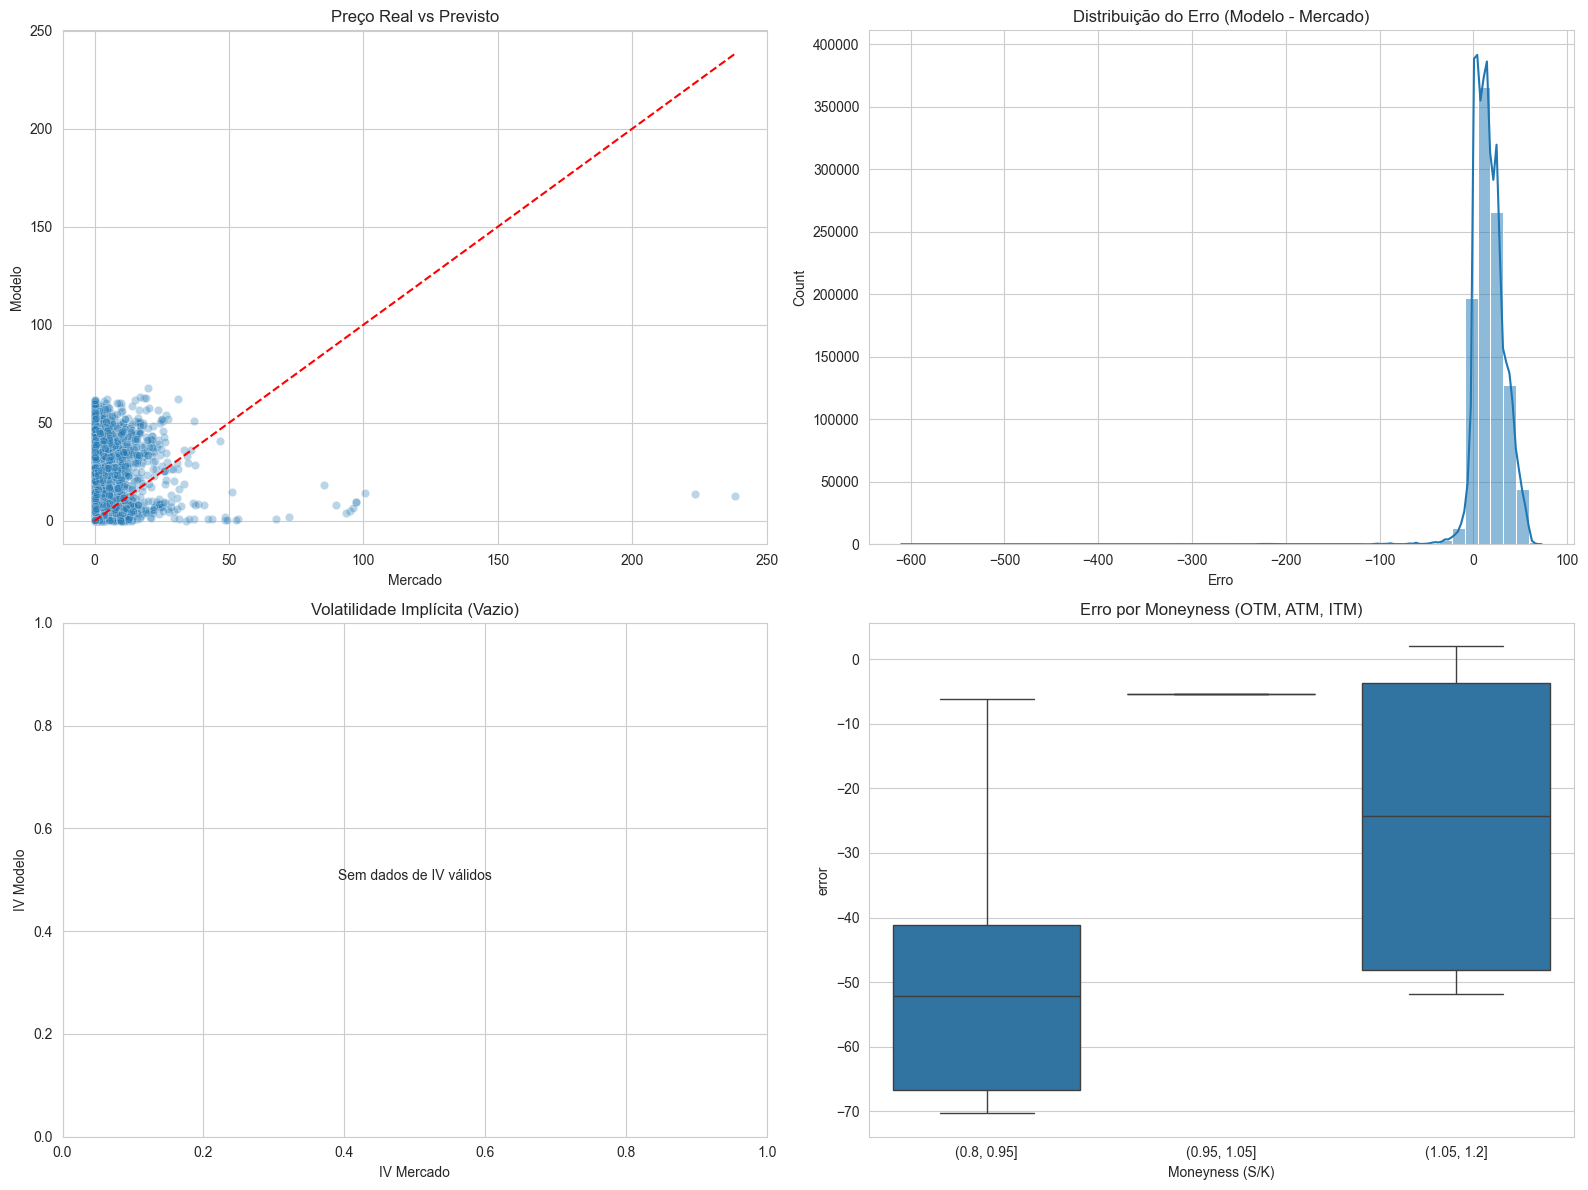

In [7]:
# 7. Visualizações

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. Scatter: Real vs Previsto
sns.scatterplot(data=df_plot, x='premium', y='model_price', alpha=0.3, ax=axes[0, 0])
axes[0, 0].plot([0, df_plot['premium'].max()], [0, df_plot['premium'].max()], 'r--')
axes[0, 0].set_title('Preço Real vs Previsto')
axes[0, 0].set_xlabel('Mercado')
axes[0, 0].set_ylabel('Modelo')

# B. Histograma de Erro
sns.histplot(df_val['error'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribuição do Erro (Modelo - Mercado)')
axes[0, 1].set_xlabel('Erro')

# C. Volatilidade Implícita: Scatter
if len(df_plot_iv) > 0:
    sns.scatterplot(data=df_plot_iv, x='iv_market', y='iv_model', alpha=0.3, ax=axes[1, 0])
    axes[1, 0].plot([0, 1], [0, 1], 'r--')
    axes[1, 0].set_title(f'Volatilidade Implícita (N={len(df_plot_iv)})')
else:
    axes[1, 0].text(0.5, 0.5, 'Sem dados de IV válidos', ha='center')
    axes[1, 0].set_title('Volatilidade Implícita (Vazio)')

axes[1, 0].set_xlabel('IV Mercado')
axes[1, 0].set_ylabel('IV Modelo')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 1)

# D. Erro por Moneyness
df_plot['moneyness'] = df_plot['spot_price'] / df_plot['strike']
sns.boxplot(data=df_plot, x=pd.cut(df_plot['moneyness'], bins=[0.8, 0.95, 1.05, 1.2]), y='error', ax=axes[1, 1])
axes[1, 1].set_title('Erro por Moneyness (OTM, ATM, ITM)')
axes[1, 1].set_xlabel('Moneyness (S/K)')

plt.tight_layout()
plt.show()

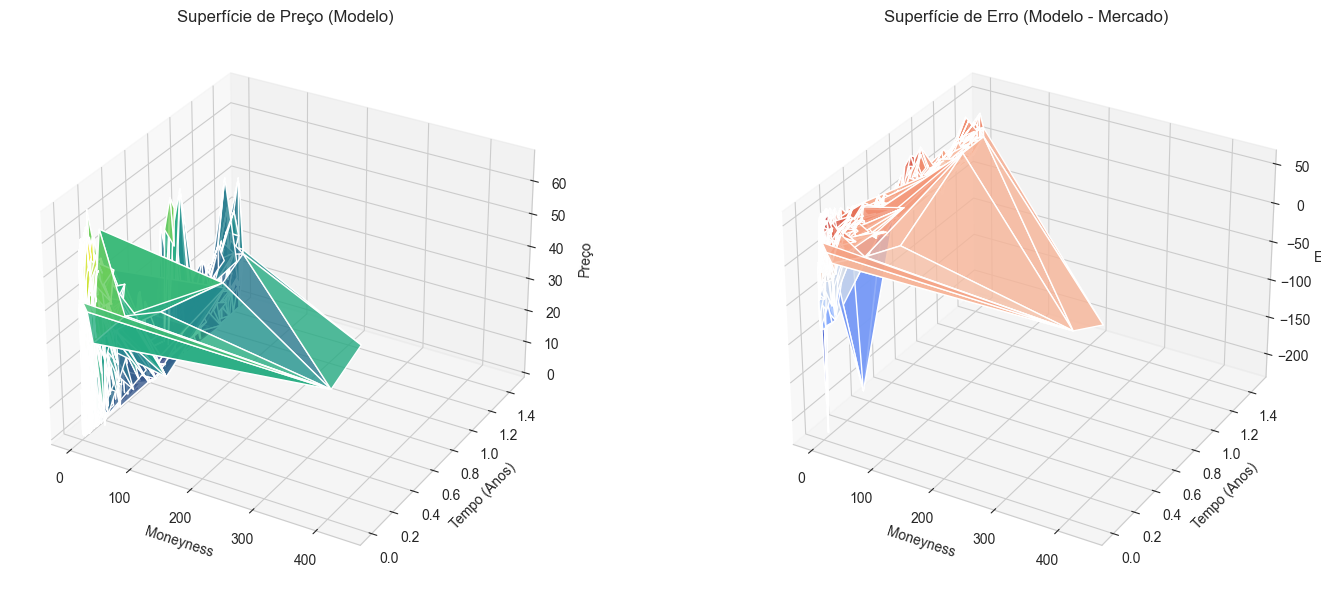

In [8]:
# 8. Surface Plots (3D)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# Superfície de Preço (Modelo)
ax1 = fig.add_subplot(121, projection='3d')

if len(df_plot) > 10:
    surf1 = ax1.plot_trisurf(df_plot['moneyness'], df_plot['time_to_maturity'], df_plot['model_price'], cmap='viridis', alpha=0.8)
else:
    ax1.text(0.5, 0.5, 0.5, "Dados insuficientes", ha='center')
    
ax1.set_title('Superfície de Preço (Modelo)')
ax1.set_xlabel('Moneyness')
ax1.set_ylabel('Tempo (Anos)')
ax1.set_zlabel('Preço')

# Superfície de Erro
ax2 = fig.add_subplot(122, projection='3d')

if len(df_plot) > 10:
    surf2 = ax2.plot_trisurf(df_plot['moneyness'], df_plot['time_to_maturity'], df_plot['error'], cmap='coolwarm', alpha=0.8)
else:
    ax2.text(0.5, 0.5, 0.5, "Dados insuficientes", ha='center')
    
ax2.set_title('Superfície de Erro (Modelo - Mercado)')
ax2.set_xlabel('Moneyness')
ax2.set_ylabel('Tempo (Anos)')
ax2.set_zlabel('Erro')

plt.tight_layout()
plt.show()

In [9]:
# 9. Quadros de Análise Qualitativa

# Categorização
df_val['moneyness'] = df_val['spot_price'] / df_val['strike']
df_val['moneyness_cat'] = pd.cut(df_val['moneyness'], 
                                 bins=[0, 0.95, 1.05, 999], 
                                 labels=['OTM', 'ATM', 'ITM'])

df_val['maturity_cat'] = pd.cut(df_val['time_to_maturity'], 
                                bins=[0, 0.1, 0.5, 999], 
                                labels=['Curto (<1m)', 'Médio (1-6m)', 'Longo (>6m)'])

# Tabela Pivô de MAE
pivot_mae = df_val.pivot_table(index='moneyness_cat', columns='maturity_cat', values='abs_error', aggfunc='mean')

print("\nQuadro de Erro Médio Absoluto (MAE) por Categoria:")
display(pivot_mae.style.background_gradient(cmap='Reds', axis=None).format("{:.4f}"))

# Tabela Pivô de Viés (Erro Médio)
pivot_bias = df_val.pivot_table(index='moneyness_cat', columns='maturity_cat', values='error', aggfunc='mean')

print("\nQuadro de Viés (Erro Médio) - Positivo = Modelo Superestima:")
display(pivot_bias.style.background_gradient(cmap='coolwarm', axis=None).format("{:.4f}"))

# Salvar Predições
SAVE_PATH = os.path.join(PATHS['results_dir'], 'val_predictions_2024.csv')
df_val.to_csv(SAVE_PATH, index=False)
print(f"\nPredições salvas em: {SAVE_PATH}")


Quadro de Erro Médio Absoluto (MAE) por Categoria:


C:\Users\Rubens Molina\AppData\Local\Temp\ipykernel_61444\2501810695.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_mae = df_val.pivot_table(index='moneyness_cat', columns='maturity_cat', values='abs_error', aggfunc='mean')


maturity_cat,Curto (<1m),Médio (1-6m),Longo (>6m)
moneyness_cat,,,
OTM,57.2710,33.6592,10.8118
ATM,38.7125,17.0329,2.9778
ITM,22.0258,13.3018,8.8882


C:\Users\Rubens Molina\AppData\Local\Temp\ipykernel_61444\2501810695.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_bias = df_val.pivot_table(index='moneyness_cat', columns='maturity_cat', values='error', aggfunc='mean')



Quadro de Viés (Erro Médio) - Positivo = Modelo Superestima:


maturity_cat,Curto (<1m),Médio (1-6m),Longo (>6m)
moneyness_cat,,,
OTM,-56.8647,-33.3733,-7.3323
ATM,-38.6647,-16.8728,-1.3845
ITM,21.0470,12.3368,6.0646



Predições salvas em: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\val_predictions_2024.csv
